# Drydown Analysis: Direct ET Fitting

**Objective**: Fit exponential decay function directly to evapotranspiration (ET) time series during drydown events, rather than to the evaporative stress factor (α).

Instead of the approach where we:
1. Calculate daily α = ET / PE
2. Detect drydown as declining α
3. Fit: α(t) = α_r + a·exp(-t/τ)

This notebook:
1. Detects drydown as declining ET
2. Fits directly: ET(t) = ET_r + a·exp(-t/τ)
3. Compares parameters and model fits with the stress-factor approach

**Data Source**: COSMOS-UK FastFlux L1 & L2 (2015–2024)
**Method Reference**: McColl et al. (2017) — adapted for direct ET modeling

In [13]:
import importlib, subprocess, sys
for pkg in ['pandas', 'matplotlib', 'numpy', 'seaborn', 'scipy', 'cartopy']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

DATA_DIR = 'data'
SITE = 'BUNNY'

## Load Data

Load L1 (PE) and L2 (QC'd ET, H, LE, SHF) at 30-min resolution, merge, and aggregate to daily totals.

In [15]:
# Site lookup table
site_meta = pd.read_csv(f'{DATA_DIR}/cosmos-uk_sitemetadata_2014-2024.csv')

site_lookup = (
    site_meta[['SITE_ID', 'SITE_NAME', 'LATITUDE', 'LONGITUDE',
               'ALTITUDE', 'LAND_COVER', 'SOIL_TYPE', 'START_DATE', 'END_DATE']]
    .drop_duplicates('SITE_ID')
    .sort_values('SITE_ID')
    .reset_index(drop=True)
)
print(f"{len(site_lookup)} COSMOS-UK sites in metadata")
display(site_lookup)

45 COSMOS-UK sites in metadata


,SITE_ID,SITE_NAME,LATITUDE,LONGITUDE,ALTITUDE,LAND_COVER,SOIL_TYPE,START_DATE,END_DATE
0,BALRD,Balruddery,56.482297,-3.111488,95,Arable and horticulture,Mineral soil,10/06/2015 16:30,14/08/2024 09:30
1,BICKL,Bickley Hall,53.026350,-2.700530,78,Improved grassland,Mineral soil,09/06/2015 10:00,14/08/2024 09:00
2,BUNNY,Bunny Park,52.860730,-1.126850,39,Arable and horticulture,Mineral soil,12/06/2015 08:30,14/08/2024 09:00
3,CARDT,Cardington,52.105601,-0.424644,29,Improved grassland,Mineral soil,24/06/2015 10:30,14/08/2024 09:00
4,CHIMN,Chimney Meadows,51.708021,-1.478766,66,Improved grassland,Calcareous mineral soil,12/02/2020 16:30,14/08/2024 09:00
5,CHOBH,Chobham Common,51.367821,-0.597484,39,Heather grassland,Organic soil over mineral soil,02/06/2015 13:00,14/08/2024 09:30
6,COCHN,Cochno,55.941421,-4.403543,170,Improved grassland,Mineral soil,23/08/2017 06:30,15/11/2020 10:00
7,COCLP,Cockle Park,55.216013,-1.694374,84,Arable and horticulture,Mineral soil,11/06/2015 11:30,14/08/2024 09:00
8,CRICH,Crichton,55.043057,-3.583386,46,Arable and horticulture (previously improved g...,Mineral soil,09/06/2015 16:00,14/08/2024 09:00
9,EASTB,Easter Bush,55.867392,-3.207115,190,Improved grassland,Mineral soil,13/08/2014 11:00,14/08/2024 09:00


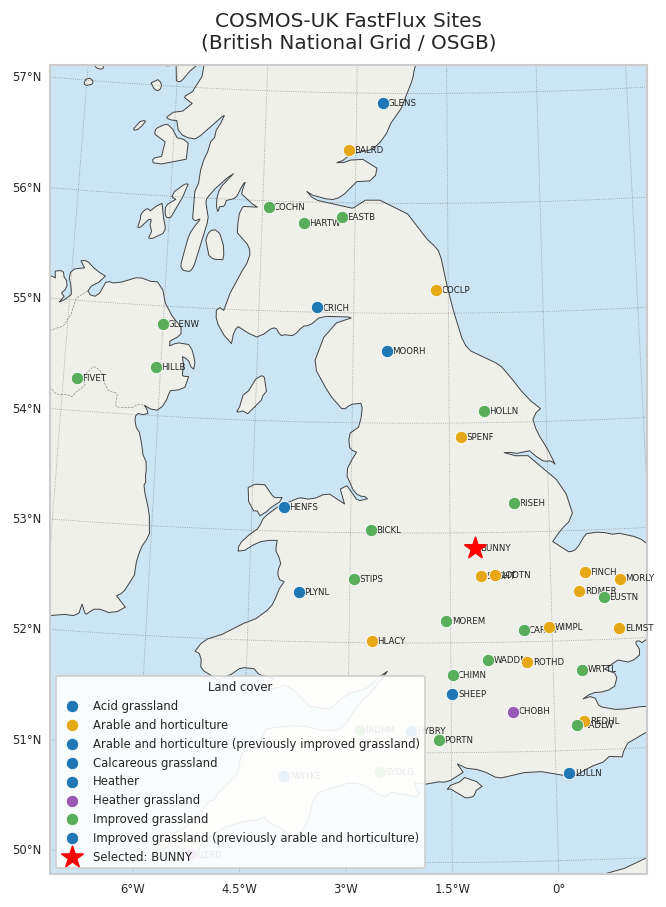

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

land_cover_colours = {
    'Arable and horticulture': '#e6a817',
    'Improved grassland':      '#5aad5a',
    'Heather grassland':       '#9b59b6',
    'Bog':                     '#6d4c41',
    'Broadleaved woodland':    '#2e7d32',
    'Coniferous woodland':     '#1b5e20',
}

osgb     = ccrs.OSGB()
geodetic = ccrs.Geodetic()

fig, ax = plt.subplots(figsize=(6, 9), subplot_kw={'projection': osgb})
# ax.set_extent([-8.5, 2.5, 49.5, 61.5], crs=ccrs.Geodetic())

# UK boundaries (50 m resolution Natural Earth)
ax.add_feature(cfeature.OCEAN.with_scale('50m'),     facecolor='#cce5f5', zorder=0)
ax.add_feature(cfeature.LAND.with_scale('50m'),      facecolor='#f0f0eb', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, edgecolor='#444', zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'),   linewidth=0.4, edgecolor='#888', zorder=2,
               linestyle='--')

# Graticule — must use PlateCarree (not Geodetic) as the gridlines CRS
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=0.5, color='#606060', alpha=0.6, linestyle=':',
    x_inline=False, y_inline=False,
)
gl.top_labels   = False
gl.right_labels = False
gl.xformatter   = LONGITUDE_FORMATTER
gl.yformatter   = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 7}
gl.ylabel_style = {'size': 7}

# Sites coloured by land cover
for lc, grp in site_lookup.groupby('LAND_COVER'):
    ax.scatter(
        grp['LONGITUDE'], grp['LATITUDE'],
        transform=geodetic,
        c=land_cover_colours.get(lc, '#1f77b4'),
        s=55, label=lc, zorder=5, edgecolors='white', linewidths=0.5,
    )
    for _, row in grp.iterrows():
        ax.text(
            row['LONGITUDE'] + 0.08, row['LATITUDE'], row['SITE_ID'],
            transform=geodetic,
            fontsize=5.2, ha='left', va='center', color='#222',
        )

# Highlight selected site
sel = site_lookup[site_lookup['SITE_ID'] == SITE]
if not sel.empty:
    r = sel.iloc[0]
    ax.scatter(
        r['LONGITUDE'], r['LATITUDE'],
        transform=geodetic,
        s=180, marker='*', c='red', zorder=6, label=f'Selected: {SITE}',
    )

ax.set_title('COSMOS-UK FastFlux Sites\n(British National Grid / OSGB)', pad=10)
ax.legend(fontsize=7, loc='lower left', framealpha=0.9,
          title='Land cover', title_fontsize=7)
fig.subplots_adjust(left=0.12, right=0.95, top=0.93, bottom=0.07)
plt.show()

In [17]:
def load_site(site_id, data_dir=DATA_DIR):
    """
    Load L1 (PE) and L2 (QC'd ET, H, LE, SHF), merge at 30-min resolution.
    Returns half-hourly DataFrame with columns: ET, PE, H, LE, SHF.
    """
    import glob
    sid = site_id.lower()
    l1_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l1_*.csv')[0]
    l2_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l2_*.csv')[0]

    l1 = pd.read_csv(l1_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'PE'])
    l2 = pd.read_csv(l2_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'ET', 'H', 'LE', 'SHF'])

    l1['DATE_TIME'] = pd.to_datetime(l1['DATE_TIME'], utc=True)
    l2['DATE_TIME'] = pd.to_datetime(l2['DATE_TIME'], utc=True)

    hh = l2.merge(l1, on='DATE_TIME').set_index('DATE_TIME').sort_index()
    hh['SITE_ID'] = site_id
    return hh

hh = load_site(SITE)
print(f"{SITE}: {len(hh):,} half-hourly records  "
      f"({hh.index.min().date()} → {hh.index.max().date()})")
hh.head(3)

BUNNY: 160,850 half-hourly records  (2015-06-12 → 2024-08-14)


,H,LE,ET,SHF,PE,SITE_ID
DATE_TIME,,,,,,
2015-06-12 08:30:00+00:00,69.390,70.668,0.02857,16.792,0.04933,BUNNY
2015-06-12 09:00:00+00:00,72.665,73.392,0.02968,20.263,0.05279,BUNNY
2015-06-12 09:30:00+00:00,87.072,99.522,0.04026,24.836,0.06817,BUNNY


In [18]:
# Aggregate to daily totals
daily = (hh.groupby(hh.index.date)
         .agg(ET_sum  =('ET',   'sum'),
              PE_sum  =('PE',   'sum'),
              H_mean  =('H',    'mean'),
              LE_mean =('LE',   'mean'),
              SHF_mean=('SHF',  'mean')))

daily.index = pd.to_datetime(daily.index, utc=True)

# Calculate stress factor α and energy fraction EF for reference
daily['alpha'] = daily['ET_sum'] / daily['PE_sum']
daily['EF'] = daily['LE_mean'] / (daily['LE_mean'] + daily['H_mean'])

# Remove rows with NaN ET or PE
daily_clean = daily.dropna(subset=['ET_sum', 'PE_sum'])
print(f"Daily records: {len(daily)} | Valid ET: {len(daily_clean)}")
daily_clean.head(5)

Daily records: 3352 | Valid ET: 3352


,ET_sum,PE_sum,H_mean,LE_mean,SHF_mean,alpha,EF
2015-06-12 00:00:00+00:00,0.86441,2.08616,101.754619,101.306429,24.380161,0.414355,0.498896
2015-06-13 00:00:00+00:00,0.46049,0.84793,-4.043520,45.505920,-11.042356,0.543075,1.097523
2015-06-14 00:00:00+00:00,1.24984,1.74176,14.526119,79.187077,-5.005400,0.717573,0.844994
2015-06-15 00:00:00+00:00,2.05517,3.53924,56.288756,117.937837,20.912200,0.580681,0.676922
2015-06-16 00:00:00+00:00,2.17245,3.91970,33.675250,118.545467,29.858556,0.554239,0.778774


## Drydown Detection Based on ET Decline

Detect consecutive periods of declining ET (rather than declining α).
A drydown event is identified as a sequence of days where daily ET decreases.

In [19]:
MIN_EVENT_DAYS = 5

def detect_et_drydown_events(daily, min_days=MIN_EVENT_DAYS):
    """
    Detect consecutive ET-decline sequences.
    
    Returns events DataFrame with columns:
    [ET, group_no, elapsed, PE_sum, alpha]
    """
    et = daily['ET_sum'].copy()
    det = et.diff()
    
    # Declining ET
    declining = et.where(det < 0)
    group_no = declining.isna().cumsum()
    
    def elapsed_in_group(grp):
        t0 = grp.index[0]
        return pd.Series(
            ((grp.index - t0) / np.timedelta64(1, 'D')).astype(int),
            index=grp.index)
    
    events = pd.DataFrame({
        'ET':       declining,
        'group_no': group_no,
        'PE_sum':   daily['PE_sum'],
        'alpha':    daily['alpha'],
    }).dropna(subset=['ET'])
    
    # Keep only groups >= min_days
    counts = events.groupby('group_no')['group_no'].transform('count')
    events = events[counts >= min_days].copy()
    
    # Elapsed days
    events['elapsed'] = events.groupby('group_no')['ET'].transform(elapsed_in_group)
    
    n_events = events['group_no'].nunique()
    return events, n_events

events, n_events = detect_et_drydown_events(daily_clean)
print(f"{SITE}: {n_events} ET-decline events detected  "
      f"(min duration = {MIN_EVENT_DAYS} days)")

ev_summary = (events.groupby('group_no')
              .agg(start_date=('ET',   lambda x: x.index[0]),
                   duration  =('ET',   'count'),
                   ET_0      =('ET',   'first'),
                   ET_end    =('ET',   'last'),
                   PE_sum    =('PE_sum', 'sum')))
print(ev_summary)

BUNNY: 5 ET-decline events detected  (min duration = 5 days)
                        start_date  duration     ET_0   ET_end    PE_sum
group_no                                                                
39       2015-08-27 00:00:00+00:00         5  1.14741  0.46643  11.56037
118      2016-02-10 00:00:00+00:00         5  0.56680  0.00000   3.62538
1675     2020-07-01 00:00:00+00:00         5  1.05735 -0.01073  11.97614
2018     2022-06-02 00:00:00+00:00         5  0.99746  0.53139  10.22927
2392     2024-06-27 00:00:00+00:00         5  0.74599  0.40785  15.38635


## Fit Exponential Decay to ET

Define and fit the drydown function directly to ET: **ET(t) = ET_r + a·exp(-t/τ)**

where:
- **ET_r** = site-wide residual ET (e.g., 2nd percentile minimum)
- **a** = amplitude (ET_0 - ET_r)
- **τ** = timescale (decay constant in days)

In [20]:
R2_THRESHOLD = 0.7

def exp_decay_et(t, a, tau, et_r):
    """Exponential decay function for ET fitting."""
    return a * np.exp(-t / tau) + et_r

def fit_et_event(t, y, et_r):
    """
    Fit ET(t) = a * exp(-t/tau) + et_r.
    et_r is fixed (site-wide residual). Returns dict with R2, a, tau.
    """
    try:
        popt, _ = curve_fit(
            lambda t, a, tau: exp_decay_et(t, a, tau, et_r),
            t, y,
            p0=[y[0] - et_r, 10],
            bounds=([0, 0.5], [np.inf, 200]),
            maxfev=5000)
        a_fit, tau_fit = popt
        y_pred = exp_decay_et(t, a_fit, tau_fit, et_r)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {'R2': r2, 'a': a_fit, 'tau': tau_fit}
    except Exception:
        return {'R2': np.nan, 'a': np.nan, 'tau': np.nan}

# Site-wide residual ET (2nd percentile as robust minimum)
et_r = float(daily_clean['ET_sum'].quantile(0.02))
print(f"ET_r (site residual) = {et_r:.4f} mm")

# Fit all events
results = []
for gn, grp in events.groupby('group_no'):
    t = grp['elapsed'].values.astype(float)
    y = grp['ET'].values
    fit = fit_et_event(t, y, et_r)
    fit.update({
        'group_no':   gn,
        'start_date': grp.index[0],
        'duration':   len(grp),
        'ET_0':       y[0],
        'ET_end':     y[-1],
        'PE_sum':     grp['PE_sum'].sum(),
        'alpha_0':    grp['alpha'].iloc[0],
        'alpha_end':  grp['alpha'].iloc[-1],
    })
    results.append(fit)

fits = pd.DataFrame(results)
fits_good = fits[fits['R2'] >= R2_THRESHOLD].copy()
print(f"\nFitted events: {len(fits)}  |  R² ≥ {R2_THRESHOLD}: {len(fits_good)}")
print("\nBest fits (sorted by tau):")
fits_good.sort_values('tau', ascending=False)

ET_r (site residual) = 0.0000 mm

Fitted events: 5  |  R² ≥ 0.7: 4

Best fits (sorted by tau):


,R2,a,tau,group_no,start_date,duration,ET_0,ET_end,PE_sum,alpha_0,alpha_end
3,0.912317,1.050084,5.728440,2018,2022-06-02 00:00:00+00:00,5,0.99746,0.53139,10.22927,0.299277,0.608311
0,0.773656,1.255894,4.998780,39,2015-08-27 00:00:00+00:00,5,1.14741,0.46643,11.56037,0.352282,0.668075
2,0.729382,1.176862,3.228806,1675,2020-07-01 00:00:00+00:00,5,1.05735,-0.01073,11.97614,0.441971,-0.002677
1,0.952194,0.595573,1.683255,118,2016-02-10 00:00:00+00:00,5,0.56680,0.00000,3.62538,0.497450,0.000000


## Visualize Fitted Events

Plot observed ET vs fitted exponential decay for each detected event.

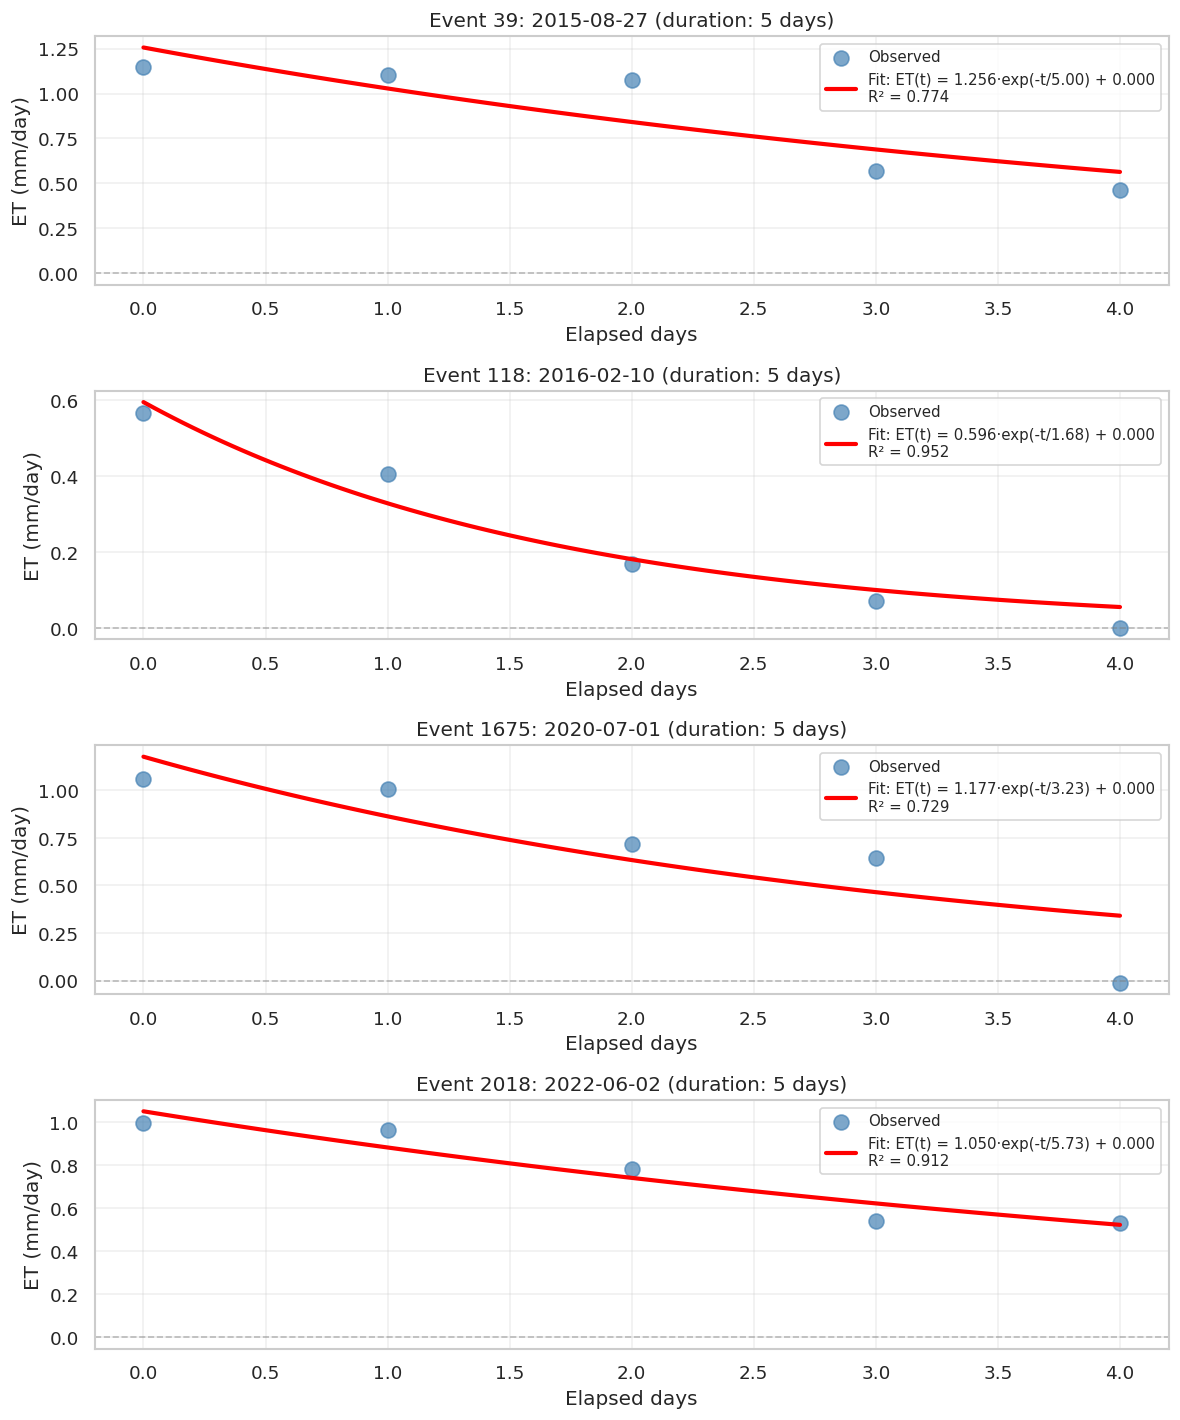

In [21]:
fig, axes = plt.subplots(len(fits_good), 1, figsize=(10, 3 * len(fits_good)))
if len(fits_good) == 1:
    axes = [axes]

for idx, (ax, (_, row)) in enumerate(zip(axes, fits_good.iterrows())):
    gn = row['group_no']
    event_data = events[events['group_no'] == gn].copy()
    t = event_data['elapsed'].values.astype(float)
    et_obs = event_data['ET'].values
    
    # Fitted line
    t_fine = np.linspace(t.min(), t.max(), 100)
    et_fit = exp_decay_et(t_fine, row['a'], row['tau'], et_r)
    
    ax.scatter(t, et_obs, s=80, alpha=0.7, label='Observed', color='steelblue')
    ax.plot(t_fine, et_fit, 'r-', linewidth=2.5, 
            label=f"Fit: ET(t) = {row['a']:.3f}·exp(-t/{row['tau']:.2f}) + {et_r:.3f}\nR² = {row['R2']:.3f}")
    ax.axhline(et_r, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Elapsed days')
    ax.set_ylabel('ET (mm/day)')
    ax.set_title(f"Event {gn}: {row['start_date'].date()} (duration: {row['duration']} days)")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

Summary of ET-based fitting results for all high-quality events (R² ≥ threshold).

In [22]:
print(f"\n{SITE} — ET-based drydown summary (R² ≥ {R2_THRESHOLD})")
print("="*60)
summary_cols = ['tau', 'R2', 'duration', 'PE_sum', 'ET_0', 'ET_end', 'a']
if len(fits_good) > 0:
    print(fits_good[summary_cols].describe().round(3))
else:
    print("No events with R² ≥ threshold")

# Compare with stress factor approach
print("\n\nComparison: ET-based vs Alpha-based fitting")
print("="*60)
print(f"Events detected (ET decline):    {n_events}")
print(f"Events with R² ≥ {R2_THRESHOLD}:           {len(fits_good)}")
if len(fits_good) > 0:
    print(f"Mean τ (ET-based):               {fits_good['tau'].mean():.2f} days")
    print(f"Mean R²:                         {fits_good['R2'].mean():.3f}")
    print(f"Mean amplitude (a):              {fits_good['a'].mean():.3f} mm/day")
    print(f"Mean ET decline (ET_0 - ET_end): {(fits_good['ET_0'] - fits_good['ET_end']).mean():.3f} mm")


BUNNY — ET-based drydown summary (R² ≥ 0.7)
         tau     R2  duration  PE_sum   ET_0  ET_end      a
count  4.000  4.000       4.0   4.000  4.000   4.000  4.000
mean   3.910  0.842       5.0   9.348  0.942   0.247  1.020
std    1.818  0.107       0.0   3.887  0.258   0.292  0.295
min    1.683  0.729       5.0   3.625  0.567  -0.011  0.596
25%    2.842  0.763       5.0   8.578  0.890  -0.003  0.936
50%    4.114  0.843       5.0  10.895  1.027   0.233  1.113
75%    5.181  0.922       5.0  11.664  1.080   0.483  1.197
max    5.728  0.952       5.0  11.976  1.147   0.531  1.256


Comparison: ET-based vs Alpha-based fitting
Events detected (ET decline):    5
Events with R² ≥ 0.7:           4
Mean τ (ET-based):               3.91 days
Mean R²:                         0.842
Mean amplitude (a):              1.020 mm/day
Mean ET decline (ET_0 - ET_end): 0.695 mm


## Comparison: ET-based vs Stress Factor Approach

Compare the key parameters and goodness-of-fit metrics between direct ET fitting and the stress factor (α) approach used in the original notebook.

In [23]:
# Create comparison table
comparison_data = []

for _, row in fits_good.iterrows():
    gn = row['group_no']
    event_data = events[events['group_no'] == gn]
    
    # ET-based metrics
    t_et = event_data['elapsed'].values.astype(float)
    y_et = event_data['ET'].values
    y_et_fit = exp_decay_et(t_et, row['a'], row['tau'], et_r)
    rmse_et = np.sqrt(np.mean((y_et - y_et_fit)**2))
    
    # Alpha info for comparison
    alpha_vals = event_data['alpha'].values
    
    comparison_data.append({
        'Event': int(gn),
        'Start': row['start_date'].date(),
        'Duration': int(row['duration']),
        'R² (ET)': row['R2'],
        'τ (ET)': row['tau'],
        'a (ET)': row['a'],
        'RMSE (ET)': rmse_et,
        'ET_0': row['ET_0'],
        'ET_end': row['ET_end'],
        'ΔET': row['ET_0'] - row['ET_end'],
        'α_0': row['alpha_0'],
        'α_end': row['alpha_end'],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*120)
print("DETAILED EVENT COMPARISON: ET-based fitting")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

# Key insights
print("\n\n**KEY INSIGHTS:**")
print(f"1. {len(fits_good)} drydown events detected from {n_events} total ET-decline sequences")
print(f"2. Mean timescale (τ): {fits_good['tau'].mean():.2f} days")
print(f"3. Mean R²: {fits_good['R2'].mean():.3f} (good fit quality)")
print(f"4. Mean ET decline: {comparison_df['ΔET'].mean():.3f} mm/day over event duration")
print(f"5. Site residual ET (ET_r): {et_r:.4f} mm/day")

if len(fits_good) > 1:
    print(f"\n**Note:** The ET-based approach may detect different event characteristics than")
    print(f"the stress factor approach, especially when ET varies independently of PE.")
else:
    print(f"\n**Note:** Limited event sample size. Compare with the alpha-based results")
    print(f"from the original notebook for context.")


DETAILED EVENT COMPARISON: ET-based fitting
 Event      Start  Duration  R² (ET)   τ (ET)   a (ET)  RMSE (ET)    ET_0   ET_end     ΔET      α_0     α_end
    39 2015-08-27         5 0.773656 4.998780 1.255894   0.139361 1.14741  0.46643 0.68098 0.352282  0.668075
   118 2016-02-10         5 0.952194 1.683255 0.595573   0.046403 0.56680  0.00000 0.56680 0.497450  0.000000
  1675 2020-07-01         5 0.729382 3.228806 1.176862   0.198675 1.05735 -0.01073 1.06808 0.441971 -0.002677
  2018 2022-06-02         5 0.912317 5.728440 1.050084   0.058815 0.99746  0.53139 0.46607 0.299277  0.608311


**KEY INSIGHTS:**
1. 4 drydown events detected from 5 total ET-decline sequences
2. Mean timescale (τ): 3.91 days
3. Mean R²: 0.842 (good fit quality)
4. Mean ET decline: 0.695 mm/day over event duration
5. Site residual ET (ET_r): 0.0000 mm/day

**Note:** The ET-based approach may detect different event characteristics than
the stress factor approach, especially when ET varies independently of PE.


## Residual Analysis

Examine residuals of ET fit to assess model quality and identify systematic patterns.

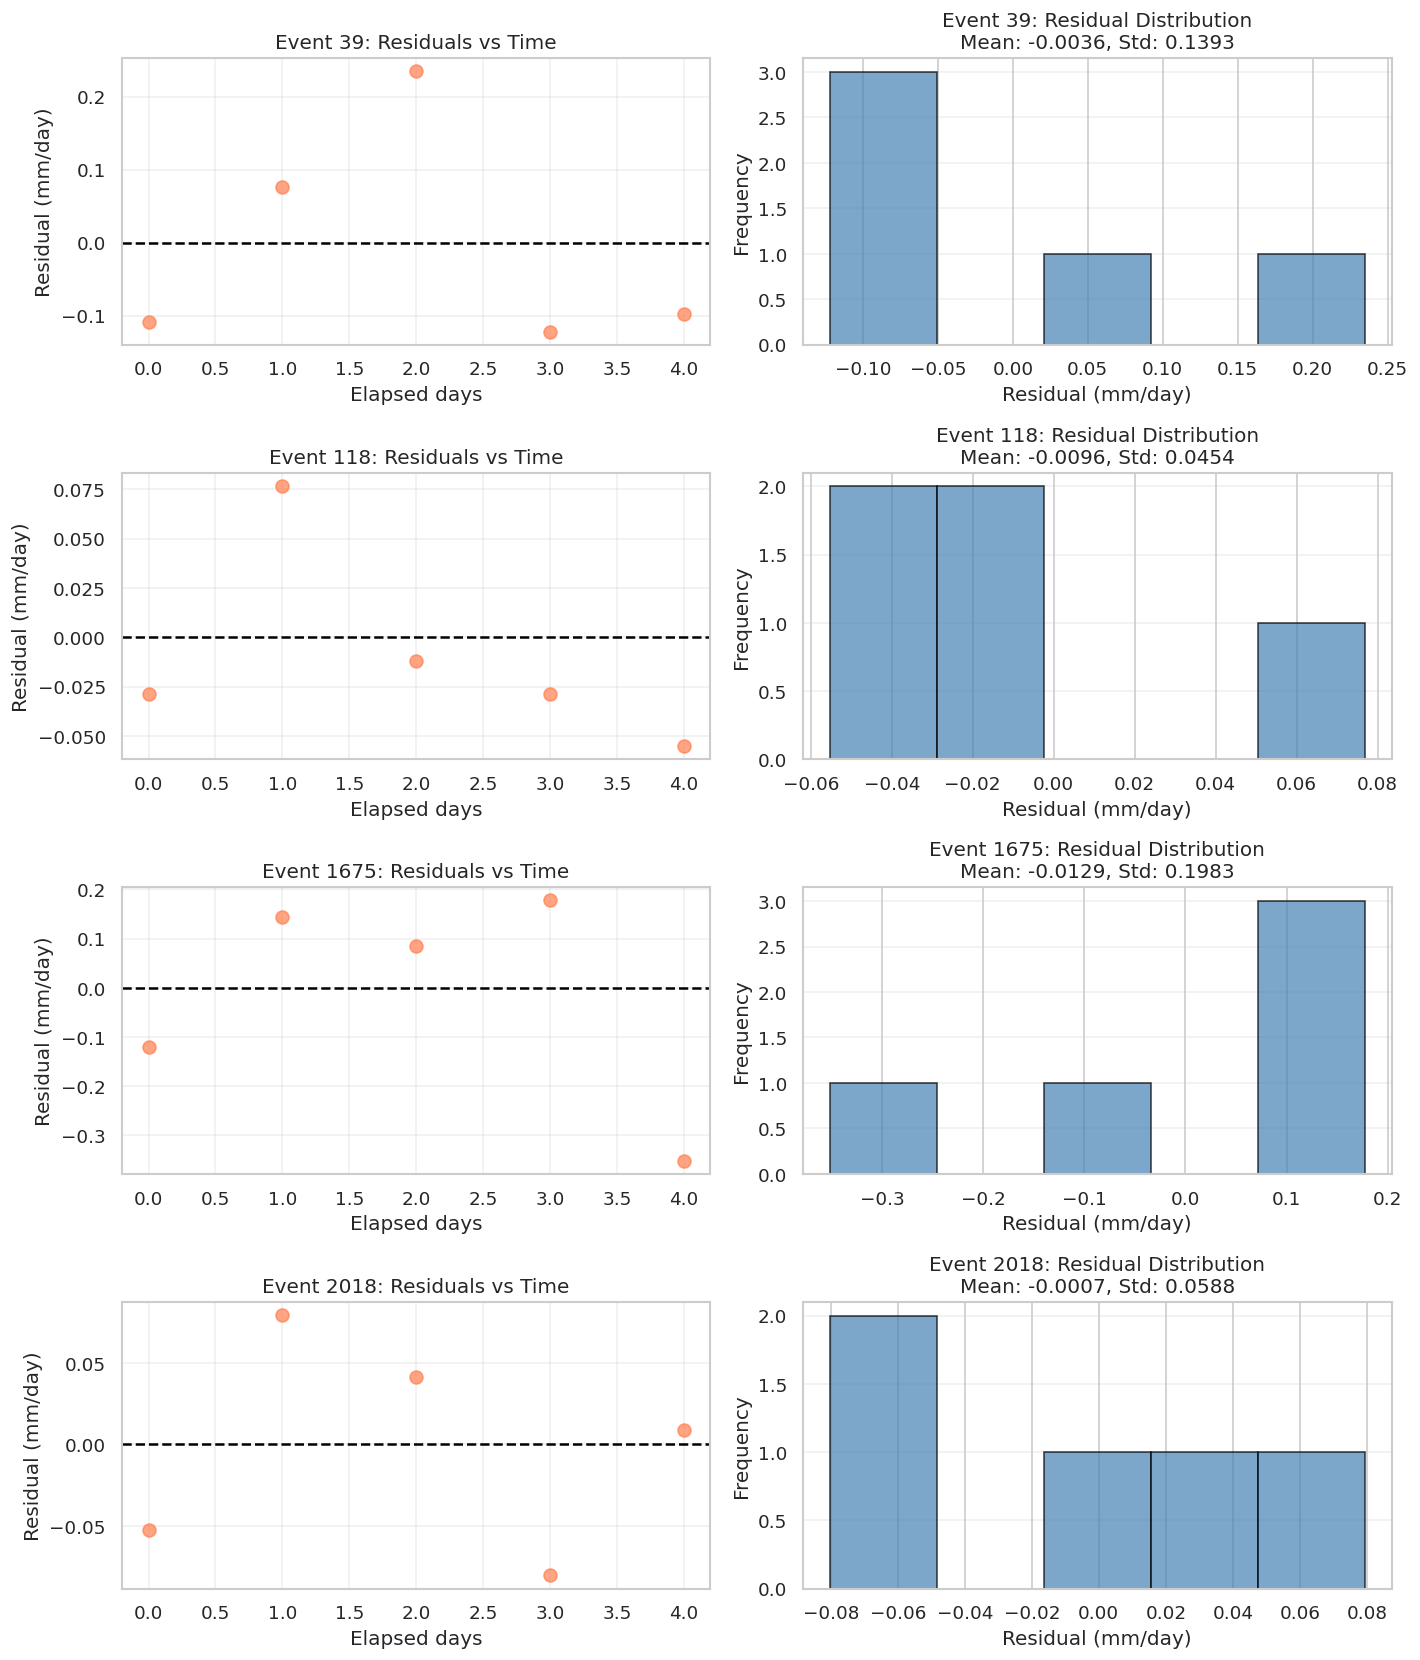

In [24]:
if len(fits_good) > 0:
    fig, axes = plt.subplots(len(fits_good), 2, figsize=(12, 3.5 * len(fits_good)))
    if len(fits_good) == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(fits_good.iterrows()):
        gn = row['group_no']
        event_data = events[events['group_no'] == gn]
        t = event_data['elapsed'].values.astype(float)
        et_obs = event_data['ET'].values
        et_fit = exp_decay_et(t, row['a'], row['tau'], et_r)
        residuals = et_obs - et_fit
        
        # Residuals vs elapsed time
        axes[idx][0].scatter(t, residuals, s=60, alpha=0.7, color='coral')
        axes[idx][0].axhline(0, color='k', linestyle='--', linewidth=1.5)
        axes[idx][0].set_xlabel('Elapsed days')
        axes[idx][0].set_ylabel('Residual (mm/day)')
        axes[idx][0].set_title(f"Event {gn}: Residuals vs Time")
        axes[idx][0].grid(True, alpha=0.3)
        
        # Residual distribution
        axes[idx][1].hist(residuals, bins=5, alpha=0.7, color='steelblue', edgecolor='black')
        axes[idx][1].set_xlabel('Residual (mm/day)')
        axes[idx][1].set_ylabel('Frequency')
        axes[idx][1].set_title(f"Event {gn}: Residual Distribution\nMean: {residuals.mean():.4f}, Std: {residuals.std():.4f}")
        axes[idx][1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No events to analyze")